# Open-source Python reproduction of the high-spin VPC benchmarks
This notebook reproduces the corrected TACT(CSS_z) benchmark and demonstrates the Python VPC calculation. It does not read saved Mathematica outputs.

In [1]:
from pathlib import Path
import sys, numpy as np, pandas as pd
ROOT=Path.cwd().parent if Path.cwd().name=='notebooks' else Path.cwd()
sys.path.insert(0,str(ROOT))
from vpc.core import *

In [2]:
rows=[]
for I in (1.5,2.5,3.5):
    t,x=first_tact_minimum(I,'ku','z')
    rows.append((I,t,x))
pd.DataFrame(rows,columns=['I','TACT_CSSz_tmin','xiS2_min'])

,I,TACT_CSSz_tmin,xiS2_min
0,1.5,0.302300,0.333333
1,2.5,0.228561,0.228094
2,3.5,0.181840,0.180091


In [3]:
targets=[(1.5,0.534),(2.5,0.408),(3.5,0.314)]
rows=[]
for I,t in targets:
    p,x=optimize_vpc_phases(I,t,metric='ku',n_starts=8,seed=20260922+int(10*I))
    rows.append((I,t,x,p))
rows

[(1.5, 0.534, 0.3333333333333346, array([0.08407079, 4.71238896, 3.05752169])),
 (2.5,
  0.408,
  0.20003367909157185,
  array([1.94933069, 5.62232467, 4.71238905, 3.8024535 , 1.19226196])),
 (3.5,
  0.314,
  0.23230588654576564,
  array([2.26439837, 2.26053004, 5.83035323, 4.76434145, 4.43736033,
         3.57504046, 1.49808626]))]

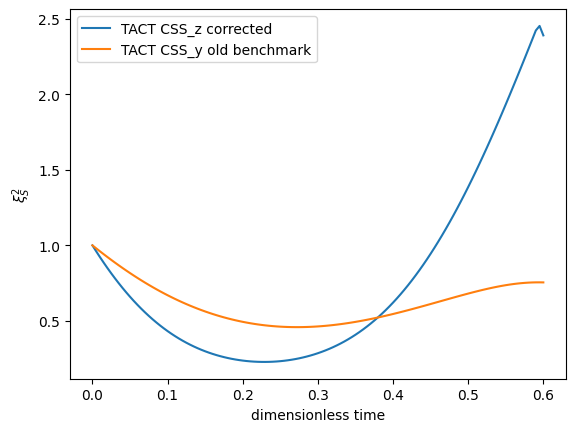

In [4]:
import matplotlib.pyplot as plt
I=2.5
t=np.linspace(0,0.6,121)
psi_z=css_state(I,0,np.pi/2)
psi_y=css_state(I,np.pi/2,np.pi/2)
yz=[xi_ku(unitary_state(h_tact(I),psi_z,x),I) for x in t]
yy=[xi_ku(unitary_state(h_tact(I),psi_y,x),I) for x in t]
plt.plot(t,yz,label='TACT CSS_z corrected')
plt.plot(t,yy,label='TACT CSS_y old benchmark')
plt.xlabel('dimensionless time'); plt.ylabel(r'$\xi_S^2$'); plt.legend(); plt.show()